# Notebook 1 : préparation des données

Projet : détection de la pollution plastique par segmentation d'images de drone.
Jeu de données : FloPWD 2025 (lac Dal, Srinagar), DOI 10.17632/znxjncgjkc.2.

Objectif : inspecter, contrôler, nettoyer et découper les données pour les phases suivantes.

Paramètres figés du projet : graine 42, taille 512×512, découpage 70 / 15 / 15.

> Ce notebook se trouve dans `notebooks/` : tous les chemins partent de `..`. Le dossier `data/raw` n'est jamais modifié.

## 1. Configuration et chemins
Imports, chemins et paramètres figés, définis une seule fois pour tout le notebook.

In [1]:
from pathlib import Path
from collections import Counter
import hashlib
import math

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from IPython.display import display
from tqdm import tqdm

# Chemins (le notebook est dans notebooks/, donc on part de "..")
RACINE = Path("..")
RAW = next((RACINE / "data" / "raw").glob("Dal Lake*"))
IMG_DIR = RAW / "Raw_Images"
MSK_DIR = RAW / "Segmentation_Masks"
PROCESSED = RACINE / "data" / "processed"
SPLITS = RACINE / "data" / "splits"
RESULTS = RACINE / "results"
for d in (PROCESSED / "images", PROCESSED / "masks", SPLITS, RESULTS):
    d.mkdir(parents=True, exist_ok=True)

# Paramètres figés
SEED = 42
TAILLE = 512
SEUIL = 127          # seuil de binarisation des masques (choisi en section 3)
TAILLE_BLOC = 50     # taille des blocs d'images consécutives pour le découpage
PARTS = {"train": 0.70, "val": 0.15, "test": 0.15}


def num(nom):
    """img12 -> 12"""
    return int(nom[3:])


print(RAW.exists(), len(list(IMG_DIR.glob("*.jpg"))), len(list(MSK_DIR.glob("*.png"))))

True 2002 2002


## 2. Format du dataset
Le jeu contient des images `.jpg` et des masques `.png`. Les masques sont déjà fournis sous forme d'images (pas de polygones à convertir). Le nom d'un masque est celui de l'image suivi de `_mask` (`img12.jpg` donne `img12_mask.png`). Deux fichiers CSV accompagnent le jeu : présence de plastique (yes / no) et pourcentage de couverture.

In [2]:
imgs = sorted(IMG_DIR.glob("*.jpg"), key=lambda p: num(p.stem))
msks = sorted(MSK_DIR.glob("*.png"), key=lambda p: num(p.stem.removesuffix("_mask")))

tailles_img, illisibles_img = Counter(), []
for p in tqdm(imgs):
    im = cv2.imread(str(p))
    if im is None:
        illisibles_img.append(p.name)
    else:
        tailles_img[im.shape[:2]] += 1

tableau = pd.DataFrame({
    "élément": ["Images", "Masques", "CSV classification", "CSV couverture"],
    "dossier": ["Raw_Images", "Segmentation_Masks", "racine", "racine"],
    "extension": [".jpg", ".png", ".csv", ".csv"],
    "nombre": [len(imgs), len(msks), 1, 1],
    "remarque": ["couleur",
                 "images, nommées imgN_mask.png (pas de polygones à convertir)",
                 "yes / no par image",
                 "pourcentage de plastique par image"],
})
display(tableau)
print("Dimensions des images (H, W) :", dict(tailles_img))
print("Images illisibles :", illisibles_img)

100%|██████████| 2002/2002 [00:43<00:00, 45.96it/s]


,élément,dossier,extension,nombre,remarque
0,Images,Raw_Images,.jpg,2002,couleur
1,Masques,Segmentation_Masks,.png,2002,"images, nommées imgN_mask.png (pas de polygone..."
2,CSV classification,racine,.csv,1,yes / no par image
3,CSV couverture,racine,.csv,1,pourcentage de plastique par image


Dimensions des images (H, W) : {(720, 1280): 2002}
Images illisibles : []


## 3. Analyse des masques et choix du seuil
Les masques ne sont pas strictement binaires : une petite part des pixels a une valeur intermédiaire entre 0 et 255 (bords des polygones adoucis). Il faut donc fixer un seuil de binarisation.

On calcule, pour plusieurs seuils, la couverture en plastique de chaque masque et on la compare au CSV de couverture fourni avec le jeu.

100%|██████████| 2002/2002 [01:12<00:00, 27.56it/s]

Dimensions des masques (H, W) : {(720, 1280): 2002}
Masques illisibles : []
Pixels à 0 : 94.469 % | à 255 : 5.384 % | gris : 0.147 %


,seuil,images avec plastique,écart moyen vs CSV,corrélation
0,> 0,1478,0.1482,0.9996
1,> 10,1478,0.0988,0.9998
2,> 50,1478,0.0880,0.9999
3,> 127,1478,0.0735,0.9999
4,> 200,1478,0.0599,0.9999


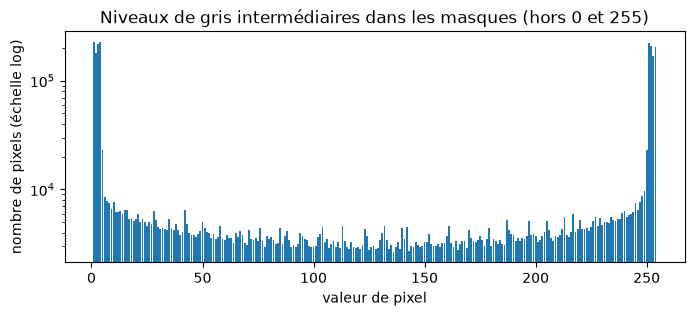

In [3]:
SEUILS = [0, 10, 50, 127, 200]

reg = pd.read_csv(next(RAW.glob("Mask_foreground*.csv")))
reg["name"] = reg["image name"].str.replace(".jpg", "", regex=False)
csv_pct = dict(zip(reg["name"], reg["plastic waste accumulation (in percentage)"]))

hist = np.zeros(256, dtype=np.int64)
lignes, tailles_msk, illisibles_msk = [], Counter(), []
for p in tqdm(msks):
    nom = p.stem.removesuffix("_mask")
    m = cv2.imread(str(p), cv2.IMREAD_UNCHANGED)
    if m is None:
        illisibles_msk.append(p.name)
        continue
    if m.ndim == 3:
        m = m.max(axis=2)
    tailles_msk[m.shape[:2]] += 1
    hist += np.bincount(m.ravel(), minlength=256)
    ligne = {"name": nom, "csv_pct": csv_pct[nom]}
    for t in SEUILS:
        ligne[f"pct_t{t}"] = 100 * (m > t).mean()
    lignes.append(ligne)

df = pd.DataFrame(lignes)
tot = hist.sum()
print("Dimensions des masques (H, W) :", dict(tailles_msk))
print("Masques illisibles :", illisibles_msk)
print(f"Pixels à 0 : {100 * hist[0] / tot:.3f} % | à 255 : {100 * hist[255] / tot:.3f} % | "
      f"gris : {100 * hist[1:255].sum() / tot:.3f} %")

resume = pd.DataFrame({
    "seuil": [f"> {t}" for t in SEUILS],
    "images avec plastique": [(df[f"pct_t{t}"] > 0).sum() for t in SEUILS],
    "écart moyen vs CSV": [(df[f"pct_t{t}"] - df.csv_pct).abs().mean().round(4) for t in SEUILS],
    "corrélation": [df[f"pct_t{t}"].corr(df.csv_pct).round(4) for t in SEUILS],
})
display(resume)

plt.figure(figsize=(8, 3))
plt.bar(range(1, 255), hist[1:255])
plt.yscale("log")
plt.title("Niveaux de gris intermédiaires dans les masques (hors 0 et 255)")
plt.xlabel("valeur de pixel")
plt.ylabel("nombre de pixels (échelle log)")
plt.savefig(RESULTS / "hist_niveaux_gris_masques.png", dpi=150, bbox_inches="tight")
plt.show()

**Résultats** : quel que soit le seuil testé (de 0 à 200), le nombre d'images avec plastique reste 1478 et la corrélation avec le CSV de couverture est de 0,9999. Les pixels intermédiaires représentent 0,147 % des pixels : le choix du seuil a très peu d'effet.

**Décision : seuil > 127** (milieu de l'échelle 0-255). La binarisation est faite en pleine résolution, avant le redimensionnement, pour ne pas mélanger de niveaux de gris.

## 4. Nettoyage
Aucun fichier de `data/raw` n'est modifié ou supprimé : le nettoyage consiste à repérer les problèmes et à les consigner dans `data/cleaning_log.csv`.

### 4.1 Contrôles de structure
Correspondance image / masque, fichiers lisibles, tailles identiques, doublons exacts.

In [4]:
noms_img = {p.stem for p in imgs}
noms_msk = {p.stem.removesuffix("_mask") for p in msks}
print("Images sans masque :", sorted(noms_img - noms_msk))
print("Masques sans image :", sorted(noms_msk - noms_img))
print("Images illisibles :", illisibles_img, "| masques illisibles :", illisibles_msk)
print("Dimensions images :", dict(tailles_img), "| masques :", dict(tailles_msk))

hashes = {}
for p in imgs:
    hashes.setdefault(hashlib.md5(p.read_bytes()).hexdigest(), []).append(p.stem)
doublons = [g for g in hashes.values() if len(g) > 1]
print("Groupes d'images identiques (doublons exacts) :", len(doublons))

Images sans masque : []
Masques sans image : []
Images illisibles : [] | masques illisibles : []
Dimensions images : {(720, 1280): 2002} | masques : {(720, 1280): 2002}
Groupes d'images identiques (doublons exacts) : 0


### 4.2 Cohérence entre les étiquettes du CSV et les masques
On compare l'étiquette « yes / no » du CSV de classification à la présence de plastique dans le masque (seuil 127).

In [5]:
lab = pd.read_csv(next(RAW.glob("Image_labels*.csv")))
lab.columns = ["image name", "label"]
lab["name"] = lab["image name"].str.replace(".jpg", "", regex=False)
d = df.merge(lab[["name", "label"]], on="name")

print("« yes » dans le CSV de classification :", (d.label == "yes").sum())
print("Masques non vides (seuil 127)         :", (d.pct_t127 > 0).sum())
print("Couverture > 0 dans le CSV de couverture :", (d.csv_pct > 0).sum())

incoherent = d[(d.label == "yes") != (d.pct_t127 > 0)].copy()
print(len(incoherent), "incohérences")
display(incoherent[["name", "label", "csv_pct", "pct_t127"]])

« yes » dans le CSV de classification : 1482
Masques non vides (seuil 127)         : 1478
Couverture > 0 dans le CSV de couverture : 1474
12 incohérences


,name,label,csv_pct,pct_t127
95,img96,yes,0.0,0.000000
339,img340,yes,0.0,0.000000
446,img447,no,0.0,0.130968
613,img614,no,0.0,0.205838
761,img762,yes,0.0,0.000000
771,img772,yes,0.0,0.000000
946,img947,yes,0.0,0.000000
999,img1000,no,0.0,0.081272
1632,img1633,yes,0.0,0.000000
1633,img1634,yes,0.0,0.000000


### 4.3 Contrôle visuel des incohérences
Le contour rouge montre où le masque place du plastique.

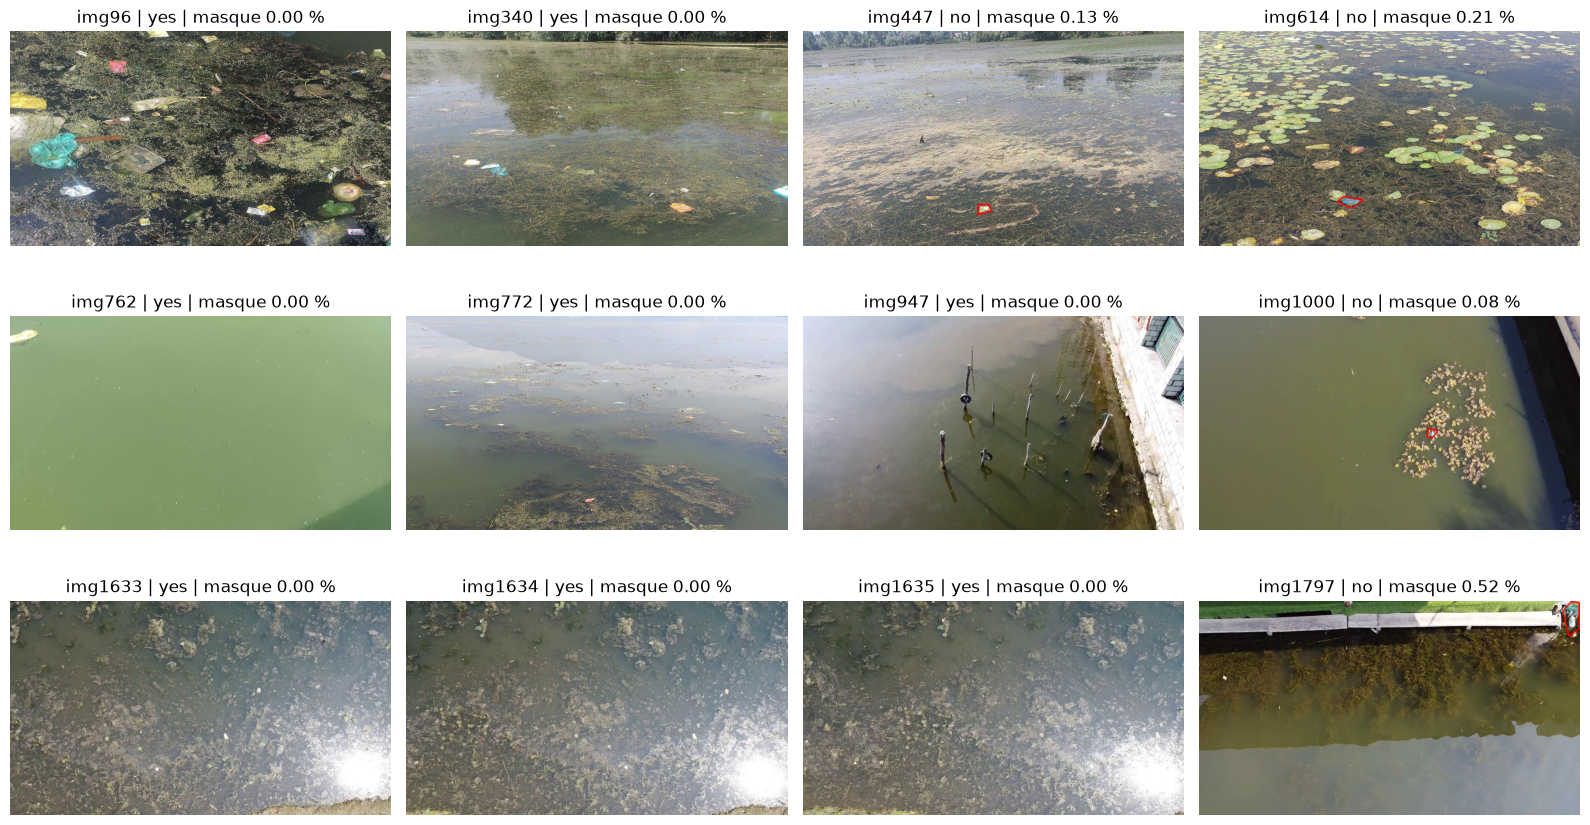

In [6]:
n = len(incoherent)
lignes_fig = max(1, math.ceil(n / 4))
fig, axes = plt.subplots(lignes_fig, 4, figsize=(16, 3 * lignes_fig), squeeze=False)
for ax in axes.ravel():
    ax.axis("off")
for ax, (_, r) in zip(axes.ravel(), incoherent.iterrows()):
    nom = r["name"]
    im = cv2.cvtColor(cv2.imread(str(IMG_DIR / f"{nom}.jpg")), cv2.COLOR_BGR2RGB)
    m = cv2.imread(str(MSK_DIR / f"{nom}_mask.png"), cv2.IMREAD_UNCHANGED)
    if m.ndim == 3:
        m = m.max(axis=2)
    cnts, _ = cv2.findContours((m > SEUIL).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(im, cnts, -1, (255, 0, 0), 3)
    ax.imshow(im)
    ax.set_title(f"{nom} | {r['label']} | masque {r['pct_t127']:.2f} %")
plt.tight_layout()
plt.savefig(RESULTS / "incoherences_controle_visuel.png", dpi=120, bbox_inches="tight")
plt.show()

### 4.4 Décisions et journal de nettoyage
- Les images « yes » dont le masque est vide : du plastique est visible sur l'image mais n'a pas été annoté. **Décision : exclues des découpages**, pour ne pas apprendre au modèle que du plastique est du fond.
- Les images « no » avec un petit masque : le masque est correct, c'est l'étiquette du CSV qui est erronée. **Décision : conservées.**

In [7]:
# Images "yes" sans masque -> exclues des découpages (data/raw reste intact)
a_exclure = incoherent.loc[incoherent.label == "yes", "name"].tolist()
print(len(a_exclure), "images exclues :", sorted(a_exclure, key=num))

journal = incoherent[["name", "label", "pct_t127"]].rename(columns={"name": "element"}).copy()
journal["probleme"] = ("étiquette " + journal["label"]
                       + ", couverture du masque = " + journal["pct_t127"].round(4).astype(str) + " %")
journal["decision"] = np.where(
    journal["element"].isin(a_exclure),
    "exclue des découpages (plastique visible, masque vide)",
    "conservée (étiquette 'no' erronée, masque correct)",
)
journal = journal[["element", "probleme", "decision"]]
journal.to_csv(RACINE / "data" / "cleaning_log.csv", index=False)
display(journal)

8 images exclues : ['img96', 'img340', 'img762', 'img772', 'img947', 'img1633', 'img1634', 'img1635']


,element,probleme,decision
95,img96,"étiquette yes, couverture du masque = 0.0 %","exclue des découpages (plastique visible, masq..."
339,img340,"étiquette yes, couverture du masque = 0.0 %","exclue des découpages (plastique visible, masq..."
446,img447,"étiquette no, couverture du masque = 0.131 %","conservée (étiquette 'no' erronée, masque corr..."
613,img614,"étiquette no, couverture du masque = 0.2058 %","conservée (étiquette 'no' erronée, masque corr..."
761,img762,"étiquette yes, couverture du masque = 0.0 %","exclue des découpages (plastique visible, masq..."
771,img772,"étiquette yes, couverture du masque = 0.0 %","exclue des découpages (plastique visible, masq..."
946,img947,"étiquette yes, couverture du masque = 0.0 %","exclue des découpages (plastique visible, masq..."
999,img1000,"étiquette no, couverture du masque = 0.0813 %","conservée (étiquette 'no' erronée, masque corr..."
1632,img1633,"étiquette yes, couverture du masque = 0.0 %","exclue des découpages (plastique visible, masq..."
1633,img1634,"étiquette yes, couverture du masque = 0.0 %","exclue des découpages (plastique visible, masq..."


Les trois décomptes du nombre d'images avec plastique s'expliquent par ces incohérences : 1482 (CSV de classification), 1478 (masques non vides), 1474 (CSV de couverture non nul). Le journal est dans `data/cleaning_log.csv`.

## 5. Statistiques
Statistiques calculées sur les images conservées (après exclusion). Le plastique occupe une faible part des pixels : l'objet à segmenter est petit par rapport à l'image, ce qui rendra l'IoU difficile à obtenir.

Nombre d'images conservées : 1994
Part d'images avec plastique : 74.1 %
Couverture moyenne (toutes images) : 5.48 %
Couverture moyenne (images avec plastique) : 7.39 %


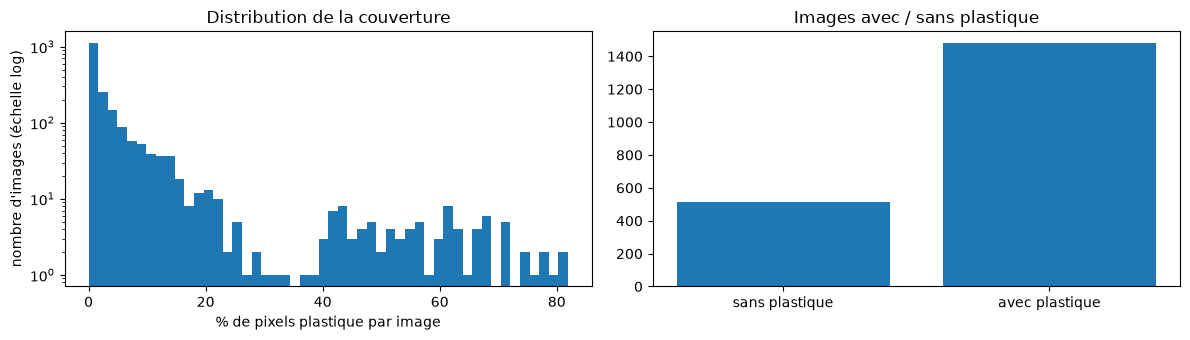

In [8]:
df_ok = df[~df.name.isin(a_exclure)].copy()
avec = df_ok.pct_t127 > 0
print("Nombre d'images conservées :", len(df_ok))
print(f"Part d'images avec plastique : {100 * avec.mean():.1f} %")
print(f"Couverture moyenne (toutes images) : {df_ok.pct_t127.mean():.2f} %")
print(f"Couverture moyenne (images avec plastique) : {df_ok.loc[avec, 'pct_t127'].mean():.2f} %")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].hist(df_ok.pct_t127, bins=50)
axes[0].set_yscale("log")
axes[0].set_xlabel("% de pixels plastique par image")
axes[0].set_ylabel("nombre d'images (échelle log)")
axes[0].set_title("Distribution de la couverture")
axes[1].bar(["sans plastique", "avec plastique"], [(~avec).sum(), avec.sum()])
axes[1].set_title("Images avec / sans plastique")
plt.tight_layout()
plt.savefig(RESULTS / "stats_couverture.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Découpage 70 / 15 / 15
Parmi 5000 répartitions aléatoires de blocs (graine 42), on retient celle qui équilibre le mieux la part d'images avec plastique et la couverture moyenne entre train, val et test. Ce critère n'utilise que les étiquettes, pas de modèle.

In [9]:
noms = sorted(df_ok.name, key=num)
blocs = {}
for nom in noms:
    blocs.setdefault((num(nom) - 1) // TAILLE_BLOC, []).append(nom)

info = df.set_index("name")
total = len(noms)

# Statistiques par bloc (dictionnaires simples pour que la recherche soit rapide)
n_b = {b: len(l) for b, l in blocs.items()}
avec_b = {b: int((info.loc[l, "pct_t127"] > 0).sum()) for b, l in blocs.items()}
pct_b = {b: float(info.loc[l, "pct_t127"].sum()) for b, l in blocs.items()}
g_avec = sum(avec_b.values()) / total
g_pct = sum(pct_b.values()) / total


def repartir(rng):
    ids = list(blocs)
    rng.shuffle(ids)
    compte = {k: 0 for k in PARTS}
    aff = {k: [] for k in PARTS}
    for b in ids:
        k = max(PARTS, key=lambda s: PARTS[s] * total - compte[s])   # l'ensemble le plus en retard
        aff[k].append(b)
        compte[k] += n_b[b]
    return aff


def ecart(aff):
    e = 0.0
    for bs in aff.values():
        n = sum(n_b[b] for b in bs)
        e += abs(sum(avec_b[b] for b in bs) / n - g_avec) / g_avec
        e += abs(sum(pct_b[b] for b in bs) / n - g_pct) / g_pct
    return e


# 5000 répartitions reproductibles (graine 42) ; on garde la plus équilibrée
rng = np.random.default_rng(SEED)
meilleure, meilleur_ecart = None, float("inf")
for _ in range(5000):
    aff = repartir(rng)
    e = ecart(aff)
    if e < meilleur_ecart:
        meilleure, meilleur_ecart = aff, e

splits = {k: [nom for b in bs for nom in blocs[b]] for k, bs in meilleure.items()}

for k, liste in splits.items():
    out = pd.DataFrame({"name": sorted(liste, key=num)})
    out["pct_plastique"] = out["name"].map(info["pct_t127"]).round(4)
    out["has_plastic"] = (out["pct_plastique"] > 0).astype(int)
    out.to_csv(SPLITS / f"{k}.csv", index=False)
    print(f"{k:5s} : {len(out):4d} images ({100 * len(out) / total:.1f} %), "
          f"{100 * out.has_plastic.mean():.1f} % avec plastique, "
          f"couverture moyenne {out.pct_plastique.mean():.2f} %")

assert not (set(splits["train"]) & set(splits["val"]))
assert not (set(splits["train"]) & set(splits["test"]))
assert not (set(splits["val"]) & set(splits["test"]))
print("Aucune image commune entre les trois ensembles")

train : 1396 images (70.0 %), 74.3 % avec plastique, couverture moyenne 5.60 %
val   :  298 images (14.9 %), 74.2 % avec plastique, couverture moyenne 5.63 %
test  :  300 images (15.0 %), 73.3 % avec plastique, couverture moyenne 4.77 %
Aucune image commune entre les trois ensembles


## 7. Redimensionnement 512×512
Les images sont redimensionnées en interpolation bilinéaire. Les masques sont d'abord binarisés (seuil > 127) en pleine résolution, puis redimensionnés avec l'interpolation au plus proche voisin : ils restent strictement en {0, 1}. Résultats dans `data/processed/images` (`.jpg`, qualité 95) et `data/processed/masks` (`.png`), avec le même nom de base.

In [10]:
tous = pd.concat([pd.read_csv(SPLITS / f"{k}.csv").assign(split=k) for k in PARTS], ignore_index=True)

for nom in tqdm(tous["name"]):
    im = cv2.imread(str(IMG_DIR / f"{nom}.jpg"))
    im = cv2.resize(im, (TAILLE, TAILLE), interpolation=cv2.INTER_LINEAR)
    cv2.imwrite(str(PROCESSED / "images" / f"{nom}.jpg"), im, [cv2.IMWRITE_JPEG_QUALITY, 95])

    m = cv2.imread(str(MSK_DIR / f"{nom}_mask.png"), cv2.IMREAD_UNCHANGED)
    if m.ndim == 3:
        m = m.max(axis=2)
    m = (m > SEUIL).astype(np.uint8)
    m = cv2.resize(m, (TAILLE, TAILLE), interpolation=cv2.INTER_NEAREST)
    cv2.imwrite(str(PROCESSED / "masks" / f"{nom}.png"), m)

print(len(tous), "paires écrites dans", PROCESSED)

100%|██████████| 1994/1994 [01:09<00:00, 28.72it/s]

1994 paires écrites dans ..\data\processed


## 8. Contrôle visuel
10 paires image + masque superposé (en rouge) tirées au hasard avec la graine 42, dont 2 sans plastique.

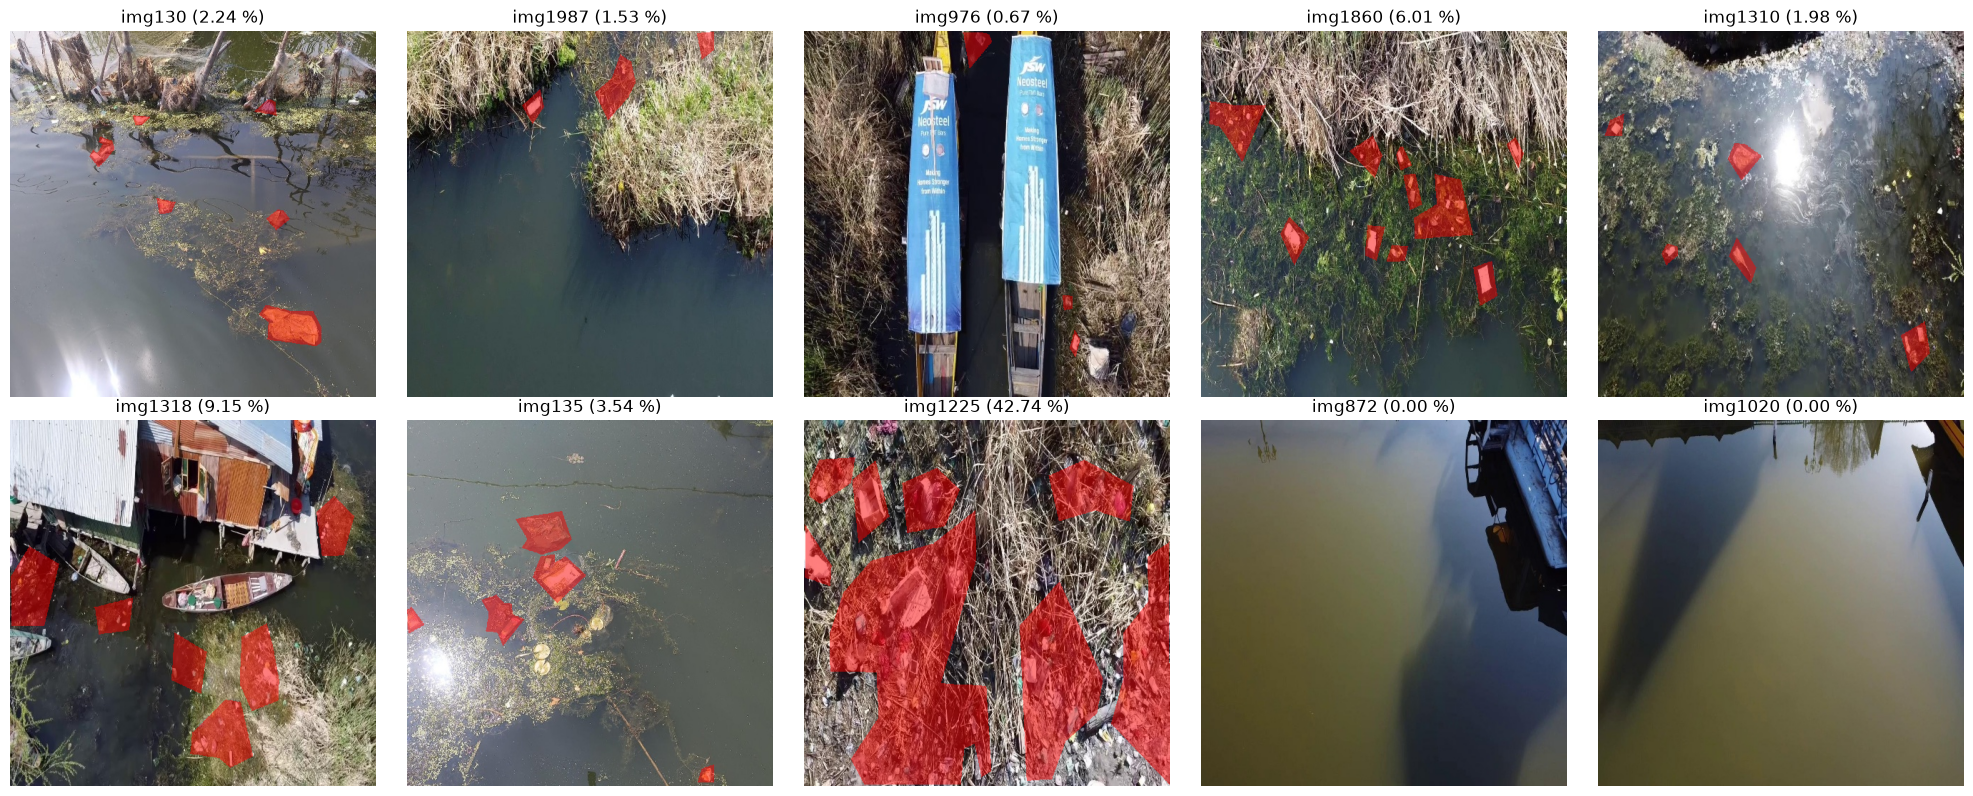

In [11]:
rng = np.random.default_rng(SEED)
avec_p = tous.loc[tous.has_plastic == 1, "name"].tolist()
sans_p = tous.loc[tous.has_plastic == 0, "name"].tolist()
choix = [str(x) for x in rng.choice(avec_p, 8, replace=False)] + \
        [str(x) for x in rng.choice(sans_p, 2, replace=False)]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for ax, nom in zip(axes.ravel(), choix):
    im = cv2.cvtColor(cv2.imread(str(PROCESSED / "images" / f"{nom}.jpg")), cv2.COLOR_BGR2RGB)
    m = cv2.imread(str(PROCESSED / "masks" / f"{nom}.png"), cv2.IMREAD_UNCHANGED)
    sur = im.copy()
    sur[m == 1] = (0.5 * sur[m == 1] + 0.5 * np.array([255, 0, 0])).astype(np.uint8)
    ax.imshow(sur)
    ax.set_title(f"{nom} ({100 * (m == 1).mean():.2f} %)")
    ax.axis("off")
plt.tight_layout()
plt.savefig(RESULTS / "controle_visuel_10_paires.png", dpi=120, bbox_inches="tight")
plt.show()

## 9. Vérifications finales
Contrôles automatiques sur `data/processed` et `data/splits` : nombres, tailles, valeurs des masques, absence d'intersection entre les découpages. Ce sont les contrôles que reprendra le script `scripts/check_data.py`.

In [12]:
erreurs = []
n_img = len(list((PROCESSED / "images").glob("*.jpg")))
n_msk = len(list((PROCESSED / "masks").glob("*.png")))
if not (n_img == n_msk == len(tous)):
    erreurs.append(f"nombres incohérents : {n_img} images, {n_msk} masques, {len(tous)} lignes de CSV")

for nom in tqdm(tous["name"]):
    im = cv2.imread(str(PROCESSED / "images" / f"{nom}.jpg"))
    m = cv2.imread(str(PROCESSED / "masks" / f"{nom}.png"), cv2.IMREAD_UNCHANGED)
    if im is None or m is None:
        erreurs.append(f"{nom} : fichier manquant ou illisible"); continue
    if im.shape != (TAILLE, TAILLE, 3) or m.shape != (TAILLE, TAILLE):
        erreurs.append(f"{nom} : mauvaise taille {im.shape} / {m.shape}")
    if not set(np.unique(m).tolist()) <= {0, 1}:
        erreurs.append(f"{nom} : valeurs de masque {np.unique(m).tolist()}")

lus = {k: set(pd.read_csv(SPLITS / f"{k}.csv")["name"]) for k in PARTS}
if lus["train"] & lus["val"] or lus["train"] & lus["test"] or lus["val"] & lus["test"]:
    erreurs.append("images communes entre les découpages")

print("TOUT EST OK" if not erreurs else f"{len(erreurs)} problème(s) :")
for e in erreurs[:20]:
    print(" -", e)

100%|██████████| 1994/1994 [00:57<00:00, 34.97it/s]

TOUT EST OK


## Limites et suite
- Un seul lac (lac Dal) : la généralisation à la mer et aux rivières reste une perspective.
- Les masques sont des annotations manuelles par polygones, avec des bords adoucis (seuil 127 retenu).
- Quelques étiquettes du CSV de classification sont incohérentes avec les masques (voir `data/cleaning_log.csv`) ; les images « yes » sans masque ont été exclues.
- Paramètres figés transmis à la phase suivante : taille 512×512, graine 42, découpage 70 / 15 / 15 par blocs de 50 images.

Prochaines étapes de la phase 1 : écrire `scripts/check_data.py`, partager `data/processed` et `data/splits`, rédiger le README des données et la note de passation.